
# Machine Learning  - Assignment 1

## Data Preprocessing

### Dataset: house prices dataset.

## Student Name: Shatha Rasmy Abu Jazar
## Student Number: 2320230176

### In this notebook, I will work on preparing the house prices dataset.  
### The goal is to clean the data and make it ready for building a regression model later.


## Import Libraries


### Before starting the analysis, I need to import the libraries that wil be used in the notebook.

### I will use:
### - `pandas` to read the CSV files and work with tables.
### - `numpy` to perform numerical operations.
### - `matplotlib` and `seaborn` to create visualizations.
### - `warnings` to hide unnecessary warning messages and keep the notebook clean.



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

# 🔴 1. Data Retrieval 


## Load the Data

### Now I will load the dataset files.

#### The assignment requires using two files:
#### - `train.csv`: this file contains the training data and the target column `SalePrice`.
#### - `test.csv`: this file contains the testing data, but it does not include `SalePrice`.

The target column is important because it is the value we want to predict later using a regression model.

Both files should be placed inside a folder called `data`.  
So the file paths will be:
- `data/train.csv`
- `data/test.csv`

I will read both files using `pd.read_csv()`.


In [2]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

## Check Dataset Shape

#### After loading the data, I will check the shape of both datasets.

#### The shape tells us:
#### - The number of rows.
#### - The number of columns.

#### This is one of the first checks we do after loading any dataset.

#### I expect the training dataset to have one more column than the testing dataset because `train.csv` contains the target column `SalePrice`, while `test.csv` does not.


In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


### Result Analysis

The output shows the number of rows and columns in each dataset.

The training dataset has one extra column compared to the testing dataset.  
This extra column is expected to be `SalePrice`, which is the target variable.

This confirms that the files were loaded correctly and that the training data contains the value we want to predict later.



## Preview the Training Data


Now I will display the first five rows of the training dataset.

This step helps me get a quick look at the structure of the data.

By looking at the first rows, I can see:
- Column names
- Example values
- Numerical and categorical features
- The target column `SalePrice`

This is useful before doing any cleaning or transformation.

The first five rows show that the dataset contains many features describing different parts of a house.

Some examples are:
- Lot information
- Building type
- Neighborhood
- Overall quality
- Basement information
- Garage information
- Sale price

This gives an initial understanding of the dataset.  
Since the dataset contains many columns, we will need to inspect data types and missing values carefully.



In [4]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Check Column Data Types

Now I will check the data types of all columns.

This is important because different types of columns need different preprocessing steps.

For example:
- Numerical columns can be used in correlation analysis.
- Categorical columns need encoding before modeling.
- Missing numerical values may be filled with the median.
- Missing categorical values may be filled with a category such as `"None"` or with the most frequent value.

This step will help me decide how to clean and transform each type of feature.


The dataset contains a mix of numerical and categorical columns.

From the output:
- `int64` and `float64` columns are numerical features.
- `object` columns are categorical features.

This confirms that the dataset needs different preprocessing methods:
- Numerical columns will be cleaned and analyzed statistically.
- Categorical columns will need missing value handling and encoding.

The output also shows that some columns have fewer non-null values, which means they contain missing values.  
These columns will be analyzed in the data cleaning section.


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
train_df.dtypes.value_counts()

object     43
int64      35
float64     3
dtype: int64

## Check Memory Usage


Before making any optimization, I will calculate how much memory the original training dataset uses.

This is useful because:
- It shows the current size of the dataset in memory.
- It gives a baseline for comparison.
- It helps explain why changing data types can be useful.

Even if this dataset is not very large, memory optimization is a good practice in real machine learning projects.



In [7]:
memory_before = train_df.memory_usage(deep=True).sum() / 1024**2

print(f"Memory usage before optimization: {memory_before:.2f} MB")

Memory usage before optimization: 3.88 MB


The output shows how much memory the training dataset uses before optimization.

This number will be used as a comparison point.  
In the next step, I will create an optimized copy of the dataset by changing some data types.

The goal is not to change the data itself, but to store it in a more memory-efficient way.


## Optimize Memory Usage

Now I will demonstrate a simple memory optimization technique.

I will create a copy of the training dataset and apply the following changes:
1. Convert text columns from `object` to `category`.
2. Downcast integer columns to smaller integer types.
3. Downcast float columns to smaller float types.

This is useful because:
- Many categorical values are repeated, so `category` can store them more efficiently.
- Some numerical columns do not need large data types like `int64` or `float64`.

I will use a copy of the dataset so the original data remains unchanged for the rest of the analysis.

The memory usage became lower after changing the data types.

This shows that data type optimization can reduce memory usage without removing data or changing the meaning of the columns.

The most important change is converting categorical text columns to `category`, because many of these columns contain repeated values.

For the rest of the notebook, I will continue using the original `train_df` and `test_df`, but this step satisfies the memory management requirement.


In [8]:
train_optimized = train_df.copy()

object_cols = train_optimized.select_dtypes(include=["object"]).columns
int_cols = train_optimized.select_dtypes(include=["int64"]).columns
float_cols = train_optimized.select_dtypes(include=["float64"]).columns

for col in object_cols:
    train_optimized[col] = train_optimized[col].astype("category")

for col in int_cols:
    train_optimized[col] = pd.to_numeric(train_optimized[col], downcast="integer")

for col in float_cols:
    train_optimized[col] = pd.to_numeric(train_optimized[col], downcast="float")

memory_after = train_optimized.memory_usage(deep=True).sum() / 1024**2

print(f"Memory usage before optimization: {memory_before:.2f} MB")
print(f"Memory usage after optimization: {memory_after:.2f} MB")
print(f"Memory saved: {memory_before - memory_after:.2f} MB")

Memory usage before optimization: 3.88 MB
Memory usage after optimization: 0.19 MB
Memory saved: 3.69 MB


# 🔴 2.Data Cleaning 


## Step 1: Missing Values Analysis
In this step, I will check for missing values in the dataset.

Missing values are very common in real-world data, and handling them correctly is very important before building any model.

However, not all missing values mean the same thing.

For example:
- If a column like `PoolQC` is missing, it might mean that the house does not have a pool.
- If `Fence` is missing, it might mean there is no fence.
- If `Alley` is missing, it might mean there is no alley access.

So before filling missing values, I need to:
1. Identify which columns have missing values
2. Check how many missing values each column has
3. Decide if missing means "unknown" or "does not exist"



In [9]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_percent = (missing / len(train_df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent.round(2)
})

missing_table

,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55
GarageQual,81,5.55



From the table, I can see which columns have missing values and how many.

Some columns have a very large number of missing values, such as:
- PoolQC
- MiscFeature
- Alley
- Fence

In these columns, missing values most likely mean that the feature does not exist in the house, not that the data is missing.

This means I should not remove these rows.  
Instead, I should replace missing values with a meaningful category such as "None".


## Fill Missing Values That Mean "No Feature"


Now I will handle missing values that actually mean that the house does not have that feature.

For example:
- No pool → PoolQC = None
- No fence → Fence = None
- No garage → GarageType = None

In these cases, replacing NaN with "None" is the correct approach.

This is better than filling with random values or removing rows because we keep useful information.


In [10]:
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence",
    "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "BsmtQual",
    "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "MasVnrType"
]

for col in none_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna("None")
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna("None")

## Fill Numerical Missing Values with Zero


Some numerical columns are related to features like:
- garage size
- basement area

If the house does not have a garage or basement, then the correct value should be 0.

So instead of leaving them as missing values, I will replace them with 0.


In [11]:
zero_cols = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
    "MasVnrArea"
]

for col in zero_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna(0)
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(0)

## Fill Remaining Missing Values


After handling special cases, there may still be missing values.

For the remaining columns:
- Numerical columns → fill with median (because it is not affected by outliers)
- Categorical columns → fill with most frequent value

This ensures that no missing values remain.


In [12]:
num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = train_df.select_dtypes(include=["object"]).columns

for col in num_cols:
    if col != "SalePrice":
        train_df[col] = train_df[col].fillna(train_df[col].median())
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(test_df[col].median())

for col in cat_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

### Final Check

Finally, I will check if there are any missing values left.
If the result is 0, it means there are no missing values left in the dataset.

Now the data is ready for:
- Outlier detection
- Data transformation
- EDA


In [13]:
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

0
0


## Step 2:  Outlier Removal 


### Outlier Analysis

Outliers are data points that are very different from the rest of the data.

In this dataset, one important example is:
- Houses with very large living area (GrLivArea) but unusually low price.

These points can affect the model negatively because:
- They can distort the relationship between features and the target
- They can make the model less accurate

Before removing any outliers, I will first visualize the distribution of the target variable (SalePrice) to understand its behavior.

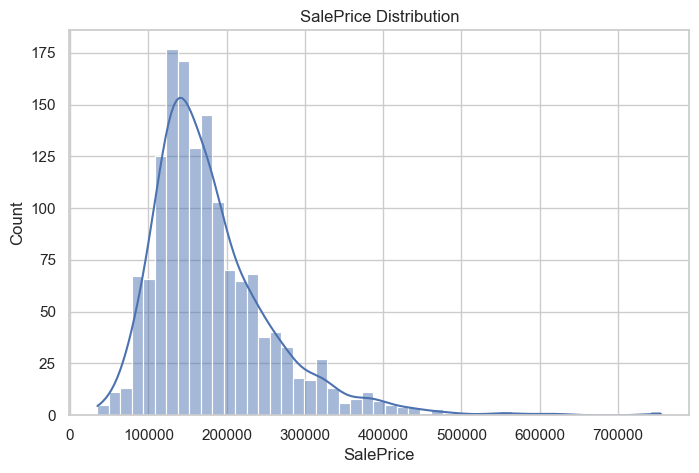

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

The distribution of SalePrice is right-skewed.

This means:
- Most houses have lower to  Midium prices
- A few houses have very high prices

This is important because:
- Many machine learning models work better when the data is more normally distributed
- We will later apply a log transformation to fix this


### Detect Outliers using Scatter Plot

Now I will visualize the relationship between:
- GrLivArea (living area)
- SalePrice

This is required in the assignment.

This plot helps to:
- Identify unusual points
- Detect houses that do not follow the general pattern

I expect to see a positive relationship:
larger houses → higher prices

Outliers will appear as points far away from this pattern.


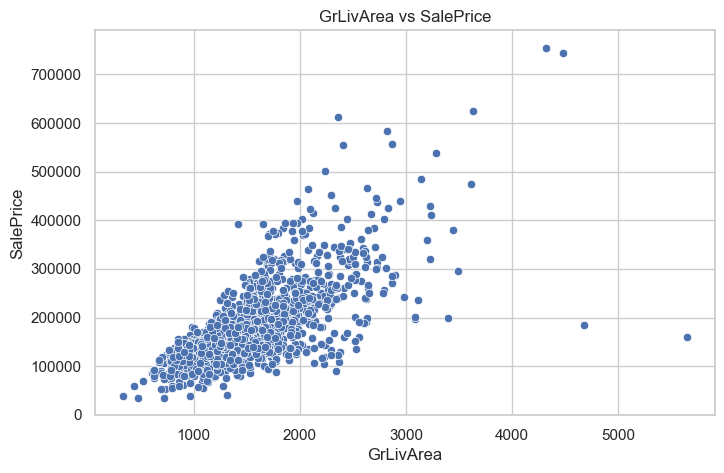

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=train_df["GrLivArea"], y=train_df["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.show()

From the scatter plot, I can clearly observe a strong positive relationship between `GrLivArea` and `SalePrice`.  
This means that, in general, larger houses tend to have higher prices, which makes sense.

However, there are some points that do not follow this pattern:

- There are a few houses with very large living area (greater than 4000 sq ft)
- But their SalePrice is relatively low compared to other houses of similar size

These points appear isolated on the right side of the plot and do not align with the general trend.

These are considered **outliers** because:
- They do not represent normal market behavior
- They can negatively affect the model by distorting the relationship between features and target

Based on this observation, it is reasonable to remove these extreme values to improve model performance.


### Remove Outliers

Now I will remove ext Ereme outliers based on GrLivArea.

A common rule is:
- Remove houses with GrLivArea > 4000 and low SalePrice

This is justified because:
- These values are very rare
- They do not represent normal market behavior

Removing them helps improve model performance.


In [16]:
train_df = train_df[~((train_df["GrLivArea"] > 4000) & (train_df["SalePrice"] < 300000))]

After remove outlires:


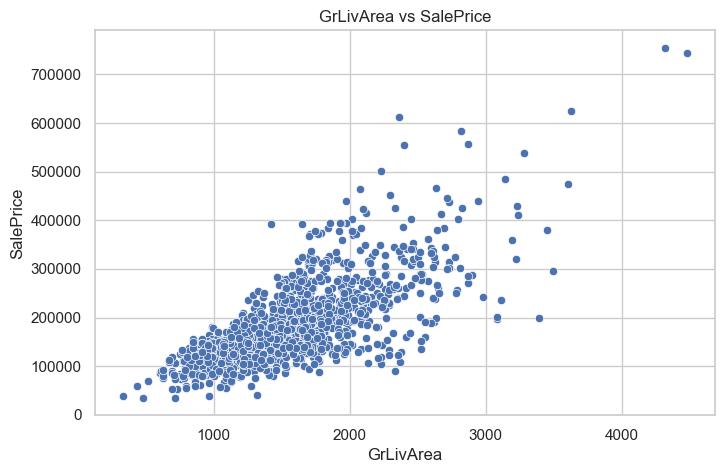

In [17]:
print('After remove outlires:')
plt.figure(figsize=(8,5))
sns.scatterplot(x=train_df["GrLivArea"], y=train_df["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.show()

The extreme outliers have been removed from the dataset.

Now:
- The relationship between GrLivArea and SalePrice is cleaner
- The remaining data better represents the general pattern

This will help the model learn a more accurate relationship and reduce the effect of unusual data points.

After removing the extreme outliers, there are still a few points with very large living area and very high prices.

These points are not considered problematic outliers because:
- They follow the general trend (larger area → higher price)
- They represent luxury houses in the dataset

Therefore, these points are kept in the dataset.


## Step 3 : Data Transformation:

### Log Transformation of SalePrice

The reason:
- SalePrice is right-skewed
- Log transformation makes the distribution more normal

We use:
np.log1p() instead of log() because it handles zero values safely

This transformation improves:
- Model performance
- Stability
- Error distribution

Before Log Transformation Of SalePrice


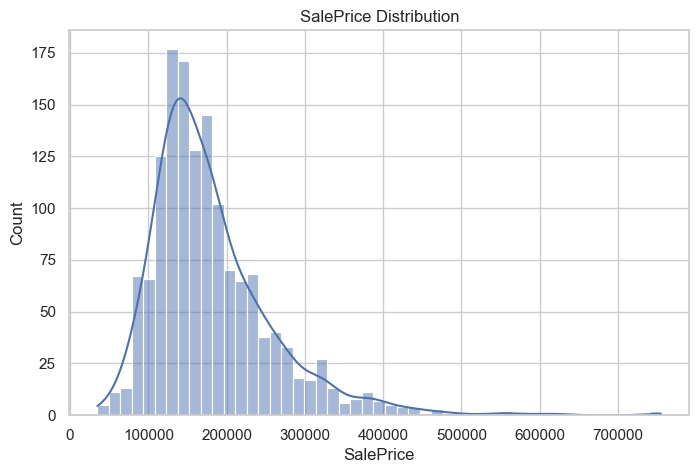

In [19]:
print("Before Log Transformation Of SalePrice")
plt.figure(figsize=(8,5))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

In [20]:
train_df["SalePrice"] = np.log1p(train_df["SalePrice"])

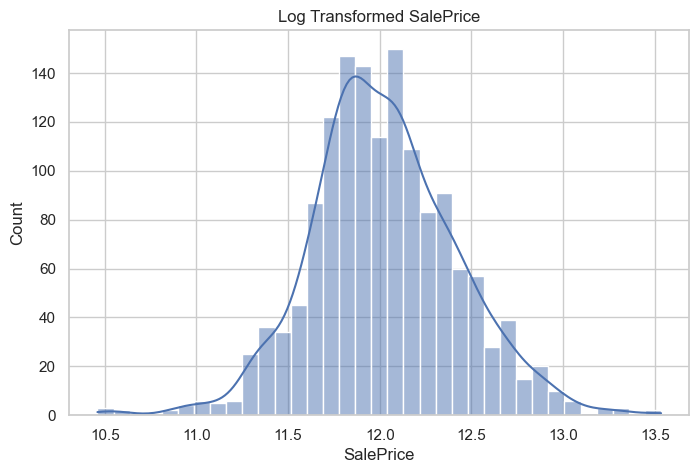

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

After applying the log transformation, the distribution is more symmetric.

This means:
- The data is now closer to normal distribution
- The model can learn better patterns

This step is very important and was required in the assignment.

#  🔴3.Exploratory Data Analysis (EDA)

## Step 1 : Correlation Analysis

### Correlation Analysis

In this step, I will analyze the relationship between numerical features and the target variable `SalePrice`.

Correlation helps us understand:
- Which features are strongly related to the target
- Which features are less useful

The correlation value ranges between:
- +1 → strong positive relationship
- 0 → no relationship
- -1 → strong negative relationship

I will compute the correlation matrix for all numerical features.

In [22]:
corr_matrix = train_df.corr(numeric_only=True)
corr_matrix.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011121,-0.020139,-0.037689,-0.030213,0.012925,-0.013463,-0.022694,-0.053952,-0.015012,...,-0.030262,-0.002115,0.003103,-0.046600,0.001491,0.048476,-0.006195,0.023511,0.000378,-0.017774
MSSubClass,0.011121,1.000000,-0.374402,-0.142033,0.032522,-0.059275,0.027757,0.040503,0.023423,-0.074434,...,-0.012681,-0.006659,-0.012002,-0.043813,-0.026004,0.008090,-0.007675,-0.013581,-0.021386,-0.073969
LotFrontage,-0.020139,-0.374402,1.000000,0.274299,0.219256,-0.050705,0.110368,0.076284,0.150829,0.133126,...,0.069811,0.105055,0.014333,0.066042,0.042121,0.100311,0.000600,0.023932,0.006792,0.351551
LotArea,-0.037689,-0.142033,0.274299,1.000000,0.091392,-0.002723,0.007462,0.007500,0.083715,0.175320,...,0.168621,0.061861,-0.016505,0.021362,0.045288,0.036491,0.039072,0.005744,-0.013699,0.260544
OverallQual,-0.030213,0.032522,0.219256,0.091392,1.000000,-0.090442,0.571368,0.549827,0.398785,0.222467,...,0.236753,0.297186,-0.113176,0.030991,0.066298,0.044758,-0.031238,0.072531,-0.026575,0.821405


The correlation matrix shows the relationship between all numerical features.

However, it is difficult to read directly, so I will visualize it using a heatmap in the next step.

### Correlation Heatmap

Now I will visualize the correlation matrix using a heatmap.

This makes it easier to:
- Identify strong relationships
- Quickly see patterns

I will focus especially on the correlation with `SalePrice`.


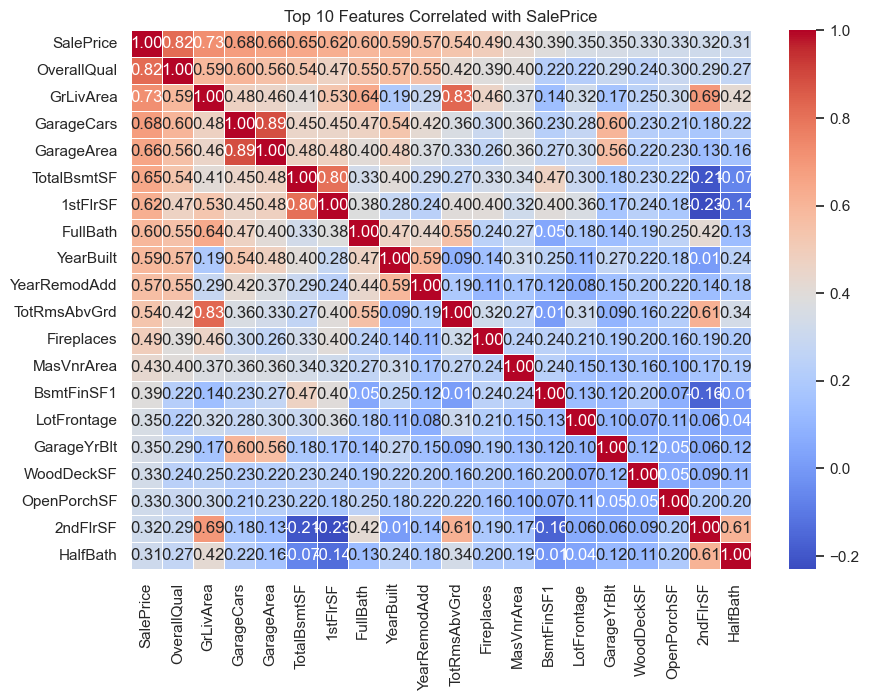

In [25]:
# Calculate correlation matrix for numerical columns
corr_matrix = train_df.corr(numeric_only=True)

# Select the top 20 features most correlated with SalePrice
top_features = corr_matrix["SalePrice"].abs().sort_values(ascending=False).head(20).index

# Create a smaller and clearer heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    train_df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Top 10 Features Correlated with SalePrice")
plt.show()

It shows the strongest numerical features related to SalePrice.  
Features such as OverallQual, GrLivArea, GarageCars, GarageArea, and TotalBsmtSF usually show strong positive correlations with SalePrice.

This means these features are likely to be important when building a regression model.


### Find Top Correlated Features with SalePrice

Now I will find the features that have the strongest correlation with `SalePrice`.

This is important because:
- These features are likely to be the most useful in prediction
- They help us understand what affects house prices the most

I will sort the correlations and select the top features.

The output shows the features most correlated with SalePrice.
These features have the strongest influence on house price.


In [26]:
top_corr = corr_matrix["SalePrice"].sort_values(ascending=False)
top_corr.head(10)

SalePrice       1.000000
OverallQual     0.821405
GrLivArea       0.725211
GarageCars      0.681033
GarageArea      0.656129
TotalBsmtSF     0.647563
1stFlrSF        0.620500
FullBath        0.595899
YearBuilt       0.587043
YearRemodAdd    0.565992
Name: SalePrice, dtype: float64

## Step 2 : Visual Exploration:

### Visual Exploration with Color

Now I will visualize the relationship between:
- GrLivArea (x-axis)
- SalePrice (y-axis)

And I will color the points based on `OverallQual`.

This helps to:
- Understand how quality affects price
- See patterns more clearly

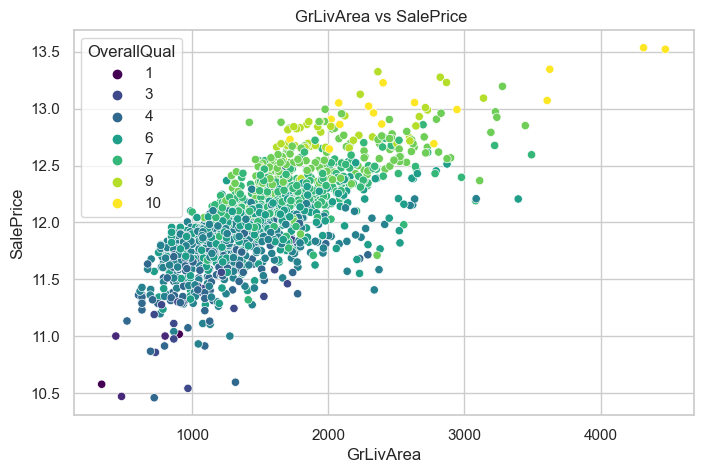

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=train_df["GrLivArea"],
    y=train_df["SalePrice"],
    hue=train_df["OverallQual"],
    palette="viridis"
)
plt.title("GrLivArea vs SalePrice ")
plt.show()

#### Interpretation of Scatter Plot (GrLivArea vs SalePrice )

From the plot, I can observe a clear positive relationship between GrLivArea and SalePrice.  
This means that as the living area increases, the house price also increases.

When adding the color based on OverallQual, the pattern becomes even clearer:
- Houses with higher quality (yellow/green colors) tend to have higher prices
- Houses with lower quality (dark blue colors) tend to have lower prices

This shows that:
- Both size (GrLivArea) and quality (OverallQual) strongly affect the price
- Even if two houses have similar size, the one with higher quality usually has a higher price

Also, the spread of points shows that:
- There is some variation, meaning other features also affect the price
- But overall, size and quality are two of the most important factors

## Step 3: Geographical Insights

### Neighborhood Analysis

Now I will analyze the average SalePrice for each Neighborhood.

This is important because location is one of the most important factors in real estate.

I will group the data by Neighborhood and calculate the average price.

In [28]:
neigh_price = train_df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)

neigh_price.head(10)

Neighborhood
NoRidge    12.676003
NridgHt    12.619415
StoneBr    12.585490
Timber     12.363460
Veenker    12.344180
Somerst    12.296500
ClearCr    12.239905
Crawfor    12.206664
Blmngtn    12.169421
CollgCr    12.163647
Name: SalePrice, dtype: float64

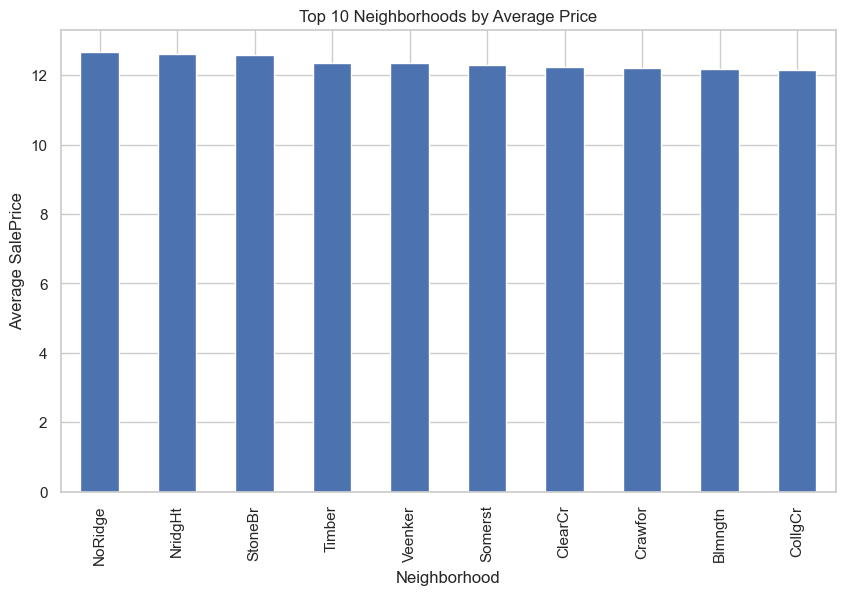

In [29]:
plt.figure(figsize=(10,6))
neigh_price.head(10).plot(kind="bar")
plt.title("Top 10 Neighborhoods by Average Price")
plt.ylabel("Average SalePrice")
plt.show()

From the bar chart, I can see that there are noticeable differences in average house prices between neighborhoods.

Some neighborhoods, such as:
- NoRidge
- NridgHt
- StoneBr

have higher average prices compared to others.

This suggests that:
- Location plays a major role in determining house prices
- Some neighborhoods are more desirable, possibly due to better infrastructure, services, or overall quality

Even though the differences are not extremely large (because of the log transformation), the ranking still shows clear variation between areas.

This confirms that the "Neighborhood" feature is important and should be included in the model.

# 🔴 4. Feature Engineering 

 ## Step 1: Feature Transformation:
 In this step, I will create a new feature called `TotalSF`.

This feature represents the total living space of the house by combining:
- Basement area (TotalBsmtSF)
- First floor area (1stFlrSF)
- Second floor area (2ndFlrSF)

The idea behind this feature is that:
- Instead of using these features separately, combining them may better represent the overall house size
- This can improve model performance



In [30]:
train_df["TotalSF"] = train_df["TotalBsmtSF"] + train_df["1stFlrSF"] + train_df["2ndFlrSF"]
test_df["TotalSF"] = test_df["TotalBsmtSF"] + test_df["1stFlrSF"] + test_df["2ndFlrSF"]

## Step 2: Encoding Categorical Variables:  
Machine learning models cannot work directly with categorical (text) data.

So, we need to convert categorical features into numerical values.

There are two main types of categorical variables:

1. Ordinal (has order)
Example: ExterQual → Poor < Fair < Good < Excellent

2. Nominal (no order)
Example: Neighborhood → just names

For this:
- Ordinal → use mapping (numbers with order)
- Nominal → use One-Hot Encoding

###  Ordinal Encoding

Now I will encode ordinal features manually using mapping.

This keeps the order of categories meaningful.

In [31]:
qual_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

qual_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "KitchenQual", "FireplaceQu"]

for col in qual_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].map(qual_map)
    if col in test_df.columns:
        test_df[col] = test_df[col].map(qual_map)

### One-Hot Encoding

Now I will apply One-Hot Encoding to nominal categorical variables.

This means:
- Each category becomes a separate column
- Values are 0 or 1

This is required because there is no order between categories.

In [32]:
train_df = pd.get_dummies(train_df)
test_df = pd.get_dummies(test_df)

### Align Train and Test Data

After encoding, train and test datasets may have different columns.

This happens because:
- Some categories exist in train but not in test

So we need to align them to have the same columns.

In [33]:
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

## Step 3: Pipeline Construction

### Building a Preprocessing Function

In this final step, I will create a reusable preprocessing function.

The purpose of this function is:
- To apply all preprocessing steps in one place
- To make sure the same steps are applied to both train and test data
- To make the workflow cleaner and more organized

Instead of writing preprocessing code multiple times, we define a function and reuse it.

This is a good practice in machine learning projects.

In [34]:
def preprocess_data(df):
    
    # Copy to avoid modifying original data
    df = df.copy()
    
    # Fill categorical "None" features
    none_cols = [
        "PoolQC", "MiscFeature", "Alley", "Fence",
        "FireplaceQu", "GarageType", "GarageFinish",
        "GarageQual", "GarageCond", "BsmtQual",
        "BsmtCond", "BsmtExposure", "BsmtFinType1",
        "BsmtFinType2", "MasVnrType"
    ]
    
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")
    
    # Fill numerical zeros
    zero_cols = [
        "GarageYrBlt", "GarageArea", "GarageCars",
        "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
        "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
        "MasVnrArea"
    ]
    
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    # Fill remaining missing values
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = df.select_dtypes(include=["object"]).columns
    
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    # Feature Engineering
    if all(col in df.columns for col in ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]):
        df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    
    # Ordinal Encoding
    qual_map = {
        "None": 0,
        "Po": 1,
        "Fa": 2,
        "TA": 3,
        "Gd": 4,
        "Ex": 5
    }
    
    qual_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "KitchenQual", "FireplaceQu"]
    
    for col in qual_cols:
        if col in df.columns:
            df[col] = df[col].map(qual_map)
    
    # One-hot encoding
    df = pd.get_dummies(df)
    
    # Log Transformation for target
    if "SalePrice" in df.columns:
        df["SalePrice"] = np.log1p(df["SalePrice"])
    
    return df

 ### Apply Preprocessing Function


Now I will apply the preprocessing function to both train and test datasets.

This ensures that:
- Both datasets go through the same transformations
- The data is ready for modeling


To ensure a clean and reproducible pipeline (one-click run), 
the raw data is reloaded and passed to the preprocessing function.

In [35]:
# Reload raw data
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

# Apply preprocessing
train_processed = preprocess_data(train_raw)
test_processed = preprocess_data(test_raw)

Both datasets have been processed using the same function.

Now:
- All missing values are handled
- Features are created
- Categorical variables are encoded

The datasets are now ready for modeling.

### Finally, I will align the processed train and test datasets to ensure they have the same columns.


In [36]:
train_processed, test_processed = train_processed.align(test_processed, join='left', axis=1, fill_value=0)

In [37]:
train_processed.isnull().sum().sum()

0

In [38]:
train_processed.dtypes.value_counts()

uint8      237
int64       41
float64      4
dtype: int64

In [39]:
train_processed.shape


(1460, 282)

In [40]:
test_processed.shape

(1459, 282)

In [41]:
set(train_processed.columns) == set(test_processed.columns)

True

In [42]:
"TotalSF" in train_processed.columns

True

In [43]:
train_processed["SalePrice"].describe()

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64

### The preprocessing pipeline is now complete.

Final Check:

- No missing values
- All features are numeric
- Train and test datasets are aligned
- Log transformation applied to SalePrice
- Feature engineering completed

The dataset is now fully prepared for machine learning modeling.